# 05 · Hydrogen is not free

Hydrogen has ~2.8× the energy per kilogram of kerosene, so the **fuel mass** drops dramatically. But that is only half the story: hydrogen has terrible **energy per litre**, and storing it (cryogenic tank or high-pressure vessel) adds a large, persistent system mass. This notebook separates the *fuel-mass win* from the *storage-and-volume penalty*.

In [1]:
# --- environment setup (educational tutorials) ---------------------------------
# These notebooks teach concepts *through* PhlyGreen. They use the real design API where
# it exists and small, clearly-labelled pedagogical proxies where it does not.
import warnings
warnings.filterwarnings("ignore")     # keep the solver's internal chatter out of the output
import numpy as np
import matplotlib.pyplot as plt

from _learning_utils import add_examples_to_path
add_examples_to_path()                # puts trunk/examples on sys.path (no absolute paths)

import PhlyGreen as pg
from PhlyGreen import postprocess as pp

from common import traditional_config, hydrogen_config

# Energy carriers — gravimetric and volumetric properties (textbook values).
LHV_kero, LHV_h2 = 43.5e6, 120e6          # [J/kg]
rho_kero, rho_LH2 = 800.0, 71.0           # [kg/m^3]  (Jet-A liquid ; liquid H2 at ~20 K)
print(f'energy per kg : kerosene {LHV_kero/1e6:.0f} MJ/kg, hydrogen {LHV_h2/1e6:.0f} MJ/kg '
      f'({LHV_h2/LHV_kero:.1f}x)')
print(f'energy per m3 : kerosene {LHV_kero*rho_kero/1e9:.1f} GJ/m3, hydrogen {LHV_h2*rho_LH2/1e9:.1f} GJ/m3 '
      f'({LHV_h2*rho_LH2/(LHV_kero*rho_kero):.2f}x)')

energy per kg : kerosene 44 MJ/kg, hydrogen 120 MJ/kg (2.8x)
energy per m3 : kerosene 34.8 GJ/m3, hydrogen 8.5 GJ/m3 (0.24x)


Per kilogram hydrogen wins ~3×; **per cubic metre it loses ~4×**. That volumetric deficit is what forces big, heavy, well-insulated tanks.

## Size a kerosene and a hydrogen aircraft for the same mission

In [2]:
a_k = pg.build_aircraft(); a_k.configure(traditional_config()); r_k = a_k.results()
a_h = pg.build_aircraft(); a_h.configure(hydrogen_config()); r_h = a_h.results()
h2_mass   = a_h.weight.WH2_Fuel
tank_mass = a_h.weight.WTank or 0.0
print(f'kerosene : WTO {r_k.WTO:8,.0f} kg | fuel {r_k.block_fuel:6,.0f} kg | powertrain {r_k.WPT:6,.0f} kg')
print(f'hydrogen : WTO {r_h.WTO:8,.0f} kg | H2   {h2_mass:6,.0f} kg | fuel-cell  {r_h.WPT:6,.0f} kg | tank {tank_mass:6,.0f} kg')

kerosene : WTO   18,327 kg | fuel  2,038 kg | powertrain  1,060 kg
hydrogen : WTO   27,745 kg | H2      549 kg | fuel-cell   4,611 kg | tank  1,019 kg


## Fuel mass vs aircraft mass

Hydrogen carries far **less fuel mass** — yet the **take-off weight is higher**. Where did the saving go? Into the fuel-cell stack and the tank. The bars below tell the story.

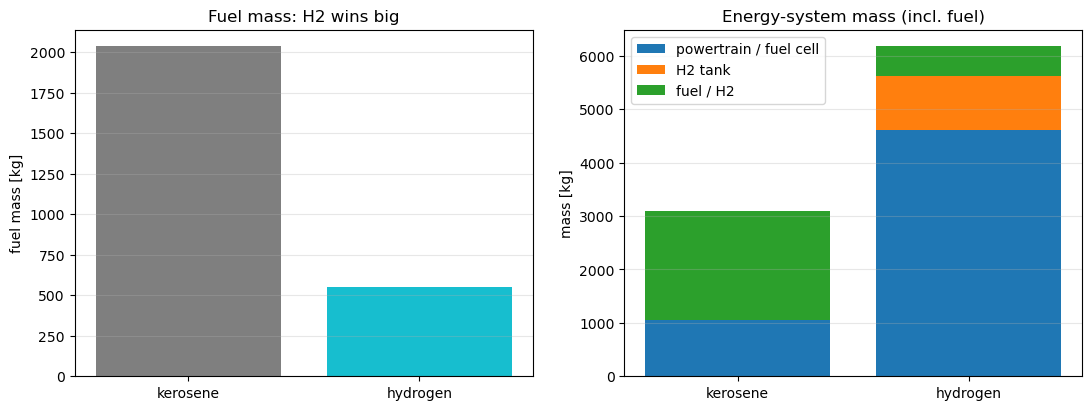

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
ax1.bar(['kerosene', 'hydrogen'], [r_k.block_fuel, h2_mass], color=['tab:gray', 'tab:cyan'])
ax1.set_ylabel('fuel mass [kg]'); ax1.set_title('Fuel mass: H2 wins big'); ax1.grid(axis='y', alpha=0.3)
# energy-system mass = powertrain (+ tank for H2); fuel shown stacked on top
labels = ['kerosene', 'hydrogen']
pt   = np.array([r_k.WPT, r_h.WPT])
tank = np.array([0.0, tank_mass])
fuel = np.array([r_k.block_fuel, h2_mass])
ax2.bar(labels, pt, label='powertrain / fuel cell', color='tab:blue')
ax2.bar(labels, tank, bottom=pt, label='H2 tank', color='tab:orange')
ax2.bar(labels, fuel, bottom=pt+tank, label='fuel / H2', color='tab:green')
ax2.set_ylabel('mass [kg]'); ax2.set_title('Energy-system mass (incl. fuel)')
ax2.legend(); ax2.grid(axis='y', alpha=0.3)
plt.show()

## Volume comparison

How much *space* does each fuel need? Using the densities above, hydrogen's low density means several times the tank volume — before insulation. (This simple calc ignores tank geometry and ullage; it is a first-order illustration.)

kerosene fuel volume :  2.55 m^3
liquid-H2  volume    :  7.73 m^3  (3.0x the kerosene volume)


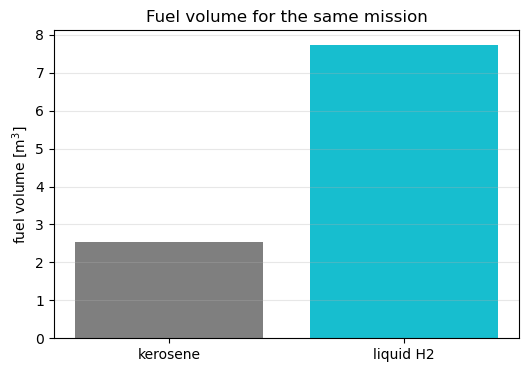

In [4]:
vol_kero = r_k.block_fuel / rho_kero      # [m^3]
vol_h2   = h2_mass / rho_LH2              # [m^3] liquid hydrogen volume
print(f'kerosene fuel volume : {vol_kero:5.2f} m^3')
print(f'liquid-H2  volume    : {vol_h2:5.2f} m^3  ({vol_h2/vol_kero:.1f}x the kerosene volume)')
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['kerosene', 'liquid H2'], [vol_kero, vol_h2], color=['tab:gray', 'tab:cyan'])
ax.set_ylabel('fuel volume [m$^3$]'); ax.set_title('Fuel volume for the same mission')
ax.grid(axis='y', alpha=0.3); plt.show()

## Sensitivity: the tank gravimetric index

The **gravimetric index** $\eta_g = m_{H_2} / (m_{H_2}+m_{tank})$ captures how good the storage is: $\eta_g=1$ is a massless tank, $\eta_g=0.3$ means the tank weighs ~2.3× the hydrogen it holds. It is the single biggest lever on whether hydrogen helps. We sweep it and watch take-off weight respond.

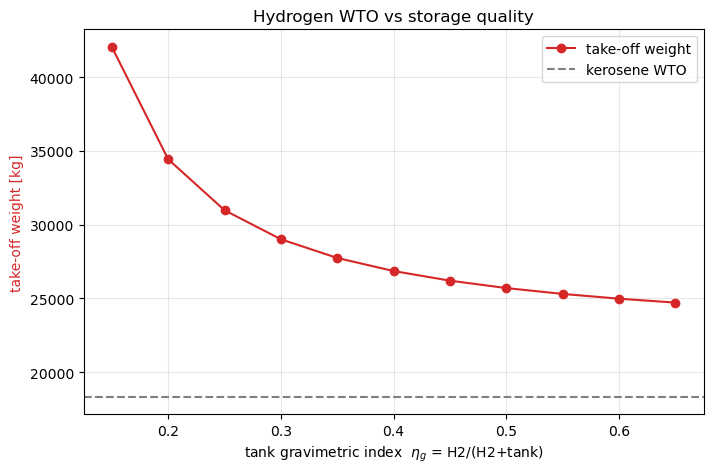

kerosene WTO = 18,327 kg (dashed line)


In [5]:
from _learning_utils import safe_design
gi_grid = np.linspace(0.15, 0.65, 11)
wto_h, tank_h = [], []
for gi in gi_grid:
    cfg = hydrogen_config(); cfg.energy.h2_gravimetric_index = float(gi)
    res, ok, note = safe_design(cfg)
    wto_h.append(res.WTO if ok else np.nan)
    # recover tank mass via a rebuilt aircraft
    if ok:
        a = pg.build_aircraft(); a.configure(cfg); tank_h.append(a.weight.WTank or 0.0)
    else:
        tank_h.append(np.nan)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(gi_grid, wto_h, 'o-', color='tab:red', label='take-off weight')
ax.set_xlabel('tank gravimetric index  $\\eta_g$ = H2/(H2+tank)')
ax.set_ylabel('take-off weight [kg]', color='tab:red')
ax.axhline(r_k.WTO, color='tab:gray', ls='--', label='kerosene WTO')
ax.set_title('Hydrogen WTO vs storage quality'); ax.grid(alpha=0.3); ax.legend()
plt.show()
print(f'kerosene WTO = {r_k.WTO:,.0f} kg (dashed line)')

As storage improves (higher $\eta_g$) the hydrogen aircraft gets lighter, but over this realistic range it stays **heavier than the kerosene baseline** — the fuel-cell stack and the irreducible tank mass don't vanish. The fuel-mass win does not translate into a take-off-weight win unless storage and powertrain get dramatically lighter.

## Key takeaways

1. Hydrogen **cuts fuel mass** (high MJ/kg) but **raises aircraft mass** here, because the fuel-cell stack and cryogenic tank are heavy and must be carried the whole flight.
2. Hydrogen's **volumetric** energy density is poor — big insulated tanks reshape the airframe, adding structure and drag.
3. **Storage architecture dominates.** The gravimetric index is the make-or-break assumption; quote any hydrogen result *with* its tank assumption.

## Questions for students

1. Why does hydrogen reduce fuel mass but not necessarily aircraft mass?
2. Why does the storage architecture (tank type, gravimetric index) matter so much?
3. What combination of assumptions would make hydrogen *attractive*? Which would make it *unattractive*? Test both on the sweep.

## Suggested modifications

- Use `hydrogen_config(tank=True)` (needs CoolProp) to size a real LH₂ tank instead of the gravimetric-index model, and compare tank masses.
- Sweep the fuel-cell `stack_power_density` to separate the *stack* penalty from the *tank* penalty.
- Try a longer design range: does hydrogen's fuel-mass advantage ever overtake its system-mass penalty?

---
*These tutorials are educational. Where the full PhlyGreen capability is not exposed (formal constraint feasibility, non-CO₂ climate weighting) the notebook uses a simplified, clearly-labelled proxy — read the comments before trusting any number.*